# ENTRENANDO MODELO DE ML PARA PREDECIR PRECIO DE AUTO USADO EN EUROPA
## DATASET: https://www.kaggle.com/datasets/alemazz11/cars-europe

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.set(style='whitegrid',context='notebook')

In [ ]:
!pip install scikit-learn==1.9.0

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv('/content/cars_cleaned.csv')
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,500,Compact,30000,17300,2022.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,14574,21900,2020.0,IT,Used,Gasoline,7.0,...,5.0,5.0,4.0,White,Cloth,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,500,Sedan,138597,8990,2009.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500C,Convertible,46500,17990,2019.0,FR,Used,Gasoline,7.0,...,5.0,5.0,3.0,Grey,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,600e,Sedan,595,32950,2025.0,DE,Used,Electric,7.0,...,5.0,5.0,4.0,Orange,Cloth,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7627,Volvo,XC40,Off-Road/Pick-up,35295,31950,2023.0,BE,Used,Electric,7.0,...,5.0,5.0,5.0,Black,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7628,Volvo,V60,Station wagon,141565,13450,2015.0,NL,Used,Gasoline,7.0,...,4.0,5.0,5.0,Blue,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7629,Volvo,V60,Station wagon,93769,22900,2020.0,IT,Used,Diesel,7.0,...,5.0,5.0,4.0,Grey,Part leather,True,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
7630,Volvo,XC40,Off-Road/Pick-up,87055,22090,2021.0,ES,Used,Electric/Gasoline,7.0,...,5.0,5.0,5.0,White,Full leather,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...


# PASO 3 - SELECCIÓN DE VARIABLES

In [ ]:
df.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url'],
      dtype='object')

In [ ]:
df = df[['Mileage_km', 'Price', 'Year',
       'Condition', 'Fuel_Type','Drivetrain', 'Gearbox',
       'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners']]

In [ ]:
df

,Mileage_km,Price,Year,Condition,Fuel_Type,Drivetrain,Gearbox,Power_hp,Engine_Size_cc,Cylinders,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,30000,17300,2022.0,Used,Gasoline,Front Wheel Drive,Manual,145,1398.0,5.0,Full leather,False,False,1.0
1,14574,21900,2020.0,Used,Gasoline,Front Wheel Drive,Manual,145,1368.0,5.0,Cloth,False,False,1.0
2,138597,8990,2009.0,Used,Gasoline,Front Wheel Drive,Manual,136,2275.0,5.0,Full leather,False,False,1.0
3,46500,17990,2019.0,Used,Gasoline,Front Wheel Drive,Manual,166,2275.0,5.0,Full leather,False,False,1.0
4,595,32950,2025.0,Used,Electric,Front Wheel Drive,Automatic,237,2275.0,5.0,Cloth,True,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7627,35295,31950,2023.0,Used,Electric,Front Wheel Drive,Automatic,231,2275.0,5.0,Full leather,False,False,1.0
7628,141565,13450,2015.0,Used,Gasoline,Front Wheel Drive,Automatic,150,1596.0,4.0,Part leather,True,False,1.0
7629,93769,22900,2020.0,Used,Diesel,4WD,Automatic,190,2275.0,5.0,Part leather,True,False,1.0
7630,87055,22090,2021.0,Used,Electric/Gasoline,4WD,Automatic,212,2275.0,5.0,Full leather,False,False,1.0


In [ ]:
df['Condition'].value_counts()

,count
Condition,
Used,7250
New,382


In [ ]:
df = df[df['Condition'] == 'Used']
df

,Mileage_km,Price,Year,Condition,Fuel_Type,Drivetrain,Gearbox,Power_hp,Engine_Size_cc,Cylinders,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners
0,30000,17300,2022.0,Used,Gasoline,Front Wheel Drive,Manual,145,1398.0,5.0,Full leather,False,False,1.0
1,14574,21900,2020.0,Used,Gasoline,Front Wheel Drive,Manual,145,1368.0,5.0,Cloth,False,False,1.0
2,138597,8990,2009.0,Used,Gasoline,Front Wheel Drive,Manual,136,2275.0,5.0,Full leather,False,False,1.0
3,46500,17990,2019.0,Used,Gasoline,Front Wheel Drive,Manual,166,2275.0,5.0,Full leather,False,False,1.0
4,595,32950,2025.0,Used,Electric,Front Wheel Drive,Automatic,237,2275.0,5.0,Cloth,True,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7627,35295,31950,2023.0,Used,Electric,Front Wheel Drive,Automatic,231,2275.0,5.0,Full leather,False,False,1.0
7628,141565,13450,2015.0,Used,Gasoline,Front Wheel Drive,Automatic,150,1596.0,4.0,Part leather,True,False,1.0
7629,93769,22900,2020.0,Used,Diesel,4WD,Automatic,190,2275.0,5.0,Part leather,True,False,1.0
7630,87055,22090,2021.0,Used,Electric/Gasoline,4WD,Automatic,212,2275.0,5.0,Full leather,False,False,1.0


In [ ]:
df = df[['Mileage_km', 'Price', 'Year', 'Fuel_Type','Power_hp', 'Engine_Size_cc', 'Cylinders']]
df

,Mileage_km,Price,Year,Fuel_Type,Power_hp,Engine_Size_cc,Cylinders
0,30000,17300,2022.0,Gasoline,145,1398.0,5.0
1,14574,21900,2020.0,Gasoline,145,1368.0,5.0
2,138597,8990,2009.0,Gasoline,136,2275.0,5.0
3,46500,17990,2019.0,Gasoline,166,2275.0,5.0
4,595,32950,2025.0,Electric,237,2275.0,5.0
...,...,...,...,...,...,...,...
7627,35295,31950,2023.0,Electric,231,2275.0,5.0
7628,141565,13450,2015.0,Gasoline,150,1596.0,4.0
7629,93769,22900,2020.0,Diesel,190,2275.0,5.0
7630,87055,22090,2021.0,Electric/Gasoline,212,2275.0,5.0


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [ ]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['Fuel_Type'], dtype='object')

In [ ]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Gasoline,3659
Electric/Gasoline,1878
Diesel,940
Electric,561
LPG,151
Electric/Diesel,34
Others,12
CNG,10
Hydrogen,5


In [ ]:
df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Gasoline' if x == 'Gasoline' else 'Other')
print(df['Fuel_Type'].value_counts())

Fuel_Type
Gasoline    3659
Other       3591
Name: count, dtype: int64


/tmp/ipykernel_35393/1279295902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fuel_Type'] = df['Fuel_Type'].apply(lambda x: 'Gasoline' if x == 'Gasoline' else 'Other')


## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
Fuel_Type
Gasoline    3659
Other       3591
Name: count, dtype: int64


In [ ]:
ordinal_cols = ['Fuel_Type']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['Fuel_Type'] []


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [ ]:
import sklearn.compose
import sklearn.preprocessing

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

## 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [ ]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__Fuel_Type,remainder__Mileage_km,remainder__Price,remainder__Year,remainder__Power_hp,remainder__Engine_Size_cc,remainder__Cylinders
0,0.0,30000.0,17300.0,2022.0,145.0,1398.0,5.0
1,0.0,14574.0,21900.0,2020.0,145.0,1368.0,5.0
2,0.0,138597.0,8990.0,2009.0,136.0,2275.0,5.0
3,0.0,46500.0,17990.0,2019.0,166.0,2275.0,5.0
4,1.0,595.0,32950.0,2025.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...
7627,1.0,35295.0,31950.0,2023.0,231.0,2275.0,5.0
7628,0.0,141565.0,13450.0,2015.0,150.0,1596.0,4.0
7629,1.0,93769.0,22900.0,2020.0,190.0,2275.0,5.0
7630,1.0,87055.0,22090.0,2021.0,212.0,2275.0,5.0


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Fuel_Type,Mileage_km,Price,Year,Power_hp,Engine_Size_cc,Cylinders
0,0.0,30000.0,17300.0,2022.0,145.0,1398.0,5.0
1,0.0,14574.0,21900.0,2020.0,145.0,1368.0,5.0
2,0.0,138597.0,8990.0,2009.0,136.0,2275.0,5.0
3,0.0,46500.0,17990.0,2019.0,166.0,2275.0,5.0
4,1.0,595.0,32950.0,2025.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...
7627,1.0,35295.0,31950.0,2023.0,231.0,2275.0,5.0
7628,0.0,141565.0,13450.0,2015.0,150.0,1596.0,4.0
7629,1.0,93769.0,22900.0,2020.0,190.0,2275.0,5.0
7630,1.0,87055.0,22090.0,2021.0,212.0,2275.0,5.0


In [ ]:
data_transformed_df.dtypes

,0
Fuel_Type,float64
Mileage_km,float64
Price,float64
Year,float64
Power_hp,float64
Engine_Size_cc,float64
Cylinders,float64


In [ ]:
data_transformed_df.to_csv('cars_transformed.csv',index=None)

In [ ]:
data_transformed_df = pd.read_csv('/content/cars_transformed.csv')
data_transformed_df

,Fuel_Type,Mileage_km,Price,Year,Power_hp,Engine_Size_cc,Cylinders
0,0.0,30000.0,17300.0,2022.0,145.0,1398.0,5.0
1,0.0,14574.0,21900.0,2020.0,145.0,1368.0,5.0
2,0.0,138597.0,8990.0,2009.0,136.0,2275.0,5.0
3,0.0,46500.0,17990.0,2019.0,166.0,2275.0,5.0
4,1.0,595.0,32950.0,2025.0,237.0,2275.0,5.0
...,...,...,...,...,...,...,...
7245,1.0,35295.0,31950.0,2023.0,231.0,2275.0,5.0
7246,0.0,141565.0,13450.0,2015.0,150.0,1596.0,4.0
7247,1.0,93769.0,22900.0,2020.0,190.0,2275.0,5.0
7248,1.0,87055.0,22090.0,2021.0,212.0,2275.0,5.0


# PASO 5 - CORRELACIONES

In [ ]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Year,0.642600
Power_hp,0.538006
Fuel_Type,0.338284
Engine_Size_cc,0.290785
Cylinders,0.147533
Mileage_km,-0.567575


<Axes: >

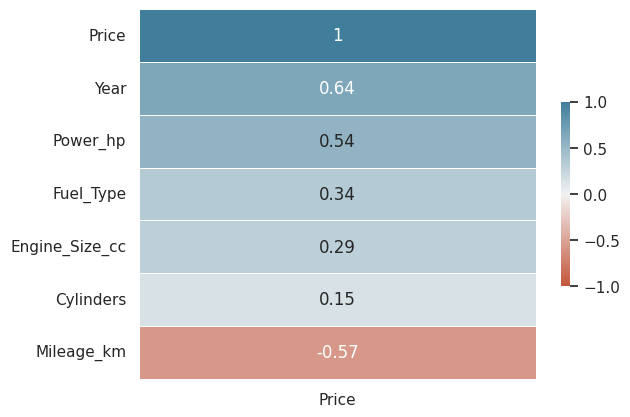

In [ ]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## PASO 6 - IDENTIFICAMOS VARIABLE X y Y , dividimos en train test

In [ ]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols

['Fuel_Type', 'Mileage_km', 'Year', 'Power_hp', 'Engine_Size_cc', 'Cylinders']

In [ ]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

## 2 - ESCALAMIENTO DE DATOS

In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

## 3 - CREAMOS DICCIONARIO DE MODELOS

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

## 4 - CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [ ]:
results = {}
for name,model in models.items():

  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [ ]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.706415,0.295451,0.401866
Lasso,0.665260,0.336868,0.434351
Ridge,0.706413,0.295453,0.401863
KNN Regressor,0.773265,0.228176,0.340495
SVR,0.756648,0.244898,0.350851
Random Forest Regressor,0.811957,0.189238,0.309980


# BUSCAMOS EL MEJOR MODELO

In [ ]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8120)
Best model based on MSE: Random Forest Regressor (MSE: 0.19)


# GRAFICAMOS RESULTADOS

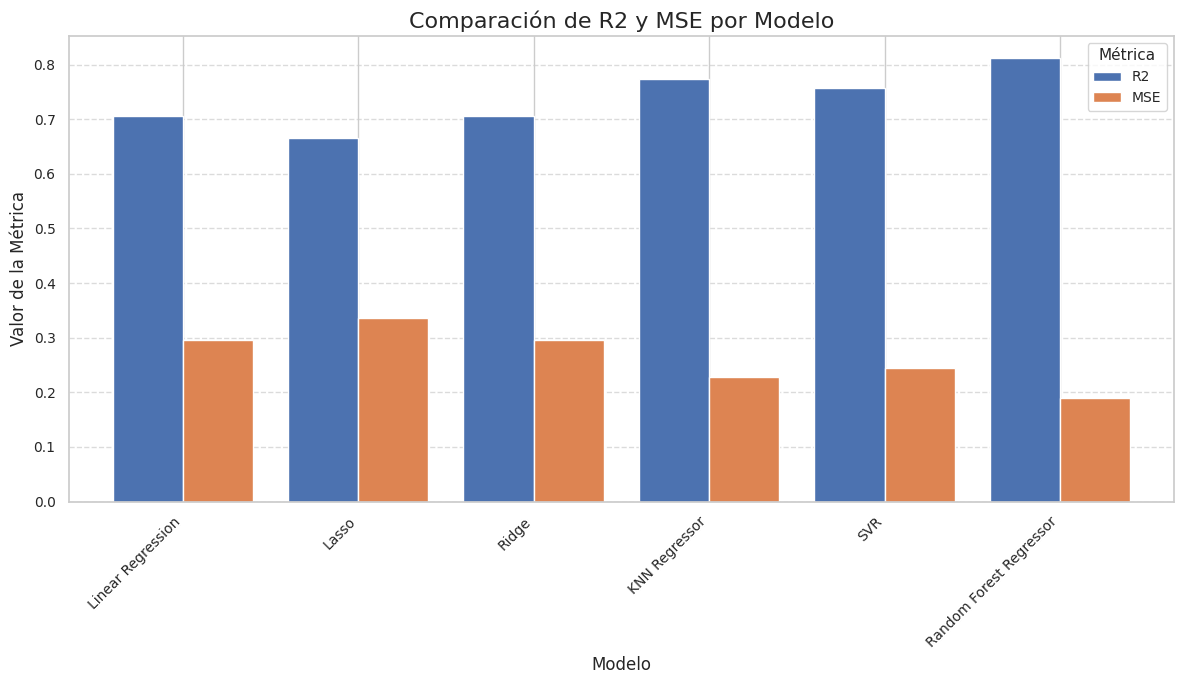

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()

# GUARDAMOS EL MEJOR MODELO Y SUS SCALERS

In [ ]:
import joblib

# Get the best model (Random Forest Regressor in this case)
best_model_name = best_r2_model # From previous cell output
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'model.pkl')

# Save the scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print(f"Best model ({best_model_name}) saved as model.pkl")
print("Scaler_X saved as scaler_X.pkl")
print("Scaler_y saved as scaler_y.pkl")

Best model (Random Forest Regressor) saved as model.pkl
Scaler_X saved as scaler_X.pkl
Scaler_y saved as scaler_y.pkl


# CARGAMOS EL MEJOR MODELO Y SUS SCALERS

In [ ]:
import joblib

# Load the best model
model = joblib.load('model.pkl')

# Load the scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

print("Model and scalers loaded successfully!")

Model and scalers loaded successfully!


# PROBAMOS EL MODELO

In [ ]:
new_car_features = [
    1.0,  # Fuel_Type (e.g., 1.0 for 'Other', 0.0 for 'Gasoline')
    50000, # Mileage_km
    2020,  # Year
    150,   # Power_hp
    1500,  # Engine_Size_cc
    4      # Cylinders
]

# Convert to numpy array and reshape for the scaler
new_car_data = np.array(new_car_features).reshape(1, -1)

# Scale the new data using the pre-fitted scaler_X
new_car_scaled = scaler_X.transform(new_car_data)

# Make a prediction with the loaded model
predicted_price_scaled = model.predict(new_car_scaled)

# Inverse transform the predicted price to the original scale
predicted_price = scaler_y.inverse_transform(predicted_price_scaled.reshape(-1, 1))

print(f"Predicted price for the new car: ${predicted_price[0][0]:,.2f}")

Predicted price for the new car: $20,827.01
